In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем файл
file_path = '/content/netflix_users_data.csv'  # ← ЗАМЕНИ!
df = pd.read_csv(file_path)

print("✅ Данные Netflix загружены!")
print(f"📊 Размер: {df.shape[0]} строк, {df.shape[1]} колонок")

# Смотрим колонки
print("\n📋 Колонки:")
print(df.columns.tolist())

print("\n📊 Первые 5 строк:")
print(df.head())

✅ Данные Netflix загружены!
📊 Размер: 2500 строк, 10 колонок

📋 Колонки:
['User ID', 'Subscription Type', 'Monthly Revenue', 'Join Date', 'Last Payment Date', 'Country', 'Age', 'Gender', 'Device', 'Plan Duration']

📊 Первые 5 строк:
   User ID Subscription Type  Monthly Revenue Join Date Last Payment Date  \
0        1             Basic               10  15-01-22          10-06-23   
1        2           Premium               15  05-09-21          22-06-23   
2        3          Standard               12  28-02-23          27-06-23   
3        4          Standard               12  10-07-22          26-06-23   
4        5             Basic               10  01-05-23          28-06-23   

          Country  Age  Gender      Device Plan Duration  
0   United States   28    Male  Smartphone       1 Month  
1          Canada   35  Female      Tablet       1 Month  
2  United Kingdom   42    Male    Smart TV       1 Month  
3       Australia   51  Female      Laptop       1 Month  
4        

In [2]:
print("\n" + "="*50)
print("🔍 АНАЛИЗ ДАННЫХ NETFLIX")
print("="*50)

print("\n📋 ВСЕ КОЛОНКИ:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

print("\n📊 ТИПЫ ДАННЫХ:")
print(df.dtypes)

print("\n📊 СТАТИСТИКА:")
print(df.describe())


🔍 АНАЛИЗ ДАННЫХ NETFLIX

📋 ВСЕ КОЛОНКИ:
   1. User ID
   2. Subscription Type
   3. Monthly Revenue
   4. Join Date
   5. Last Payment Date
   6. Country
   7. Age
   8. Gender
   9. Device
   10. Plan Duration

📊 ТИПЫ ДАННЫХ:
User ID               int64
Subscription Type    object
Monthly Revenue       int64
Join Date            object
Last Payment Date    object
Country              object
Age                   int64
Gender               object
Device               object
Plan Duration        object
dtype: object

📊 СТАТИСТИКА:
          User ID  Monthly Revenue          Age
count  2500.00000      2500.000000  2500.000000
mean   1250.50000        12.508400    38.795600
std     721.83216         1.686851     7.171778
min       1.00000        10.000000    26.000000
25%     625.75000        11.000000    32.000000
50%    1250.50000        12.000000    39.000000
75%    1875.25000        14.000000    45.000000
max    2500.00000        15.000000    51.000000


In [3]:
print("\n" + "="*50)
print("🔧 ОЧИСТКА ДАННЫХ")
print("="*50)

# Пропуски
print("📊 Пропуски:")
print(df.isna().sum())

# Удаляем пропуски
df = df.dropna()
print(f"✅ После удаления пропусков: {len(df)} строк")

# Дубликаты
duplicates = df.duplicated().sum()
print(f"📊 Дубликатов: {duplicates}")
df = df.drop_duplicates()
print(f"✅ После удаления дубликатов: {len(df)} строк")

# Преобразуем даты
date_cols = ['Join Date', 'Last Payment Date']  # названия могут отличаться!
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"✅ {col} преобразован в datetime")


🔧 ОЧИСТКА ДАННЫХ
📊 Пропуски:
User ID              0
Subscription Type    0
Monthly Revenue      0
Join Date            0
Last Payment Date    0
Country              0
Age                  0
Gender               0
Device               0
Plan Duration        0
dtype: int64
✅ После удаления пропусков: 2500 строк
📊 Дубликатов: 0
✅ После удаления дубликатов: 2500 строк
✅ Join Date преобразован в datetime
✅ Last Payment Date преобразован в datetime


/tmp/ipykernel_5482/4183307161.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/tmp/ipykernel_5482/4183307161.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [4]:
print("\n" + "="*50)
print("📊 ОБЩАЯ СТАТИСТИКА")
print("="*50)

# Найди колонки (названия могут отличаться!)
user_col = 'User ID' if 'User ID' in df.columns else df.columns[0]
sub_col = 'Subscription Type' if 'Subscription Type' in df.columns else None
revenue_col = 'Monthly Revenue' if 'Monthly Revenue' in df.columns else None
join_col = 'Join Date' if 'Join Date' in df.columns else None
country_col = 'Country' if 'Country' in df.columns else None
device_col = 'Device' if 'Device' in df.columns else None
age_col = 'Age' if 'Age' in df.columns else None
gender_col = 'Gender' if 'Gender' in df.columns else None

print(f"📊 Всего пользователей: {df[user_col].nunique()}")
print(f"📊 Период: {df[join_col].min()} - {df[join_col].max()}" if join_col else "📊 Период: не определен")

if revenue_col:
    print(f"📊 Средняя месячная выручка: {df[revenue_col].mean():.2f}")
    print(f"📊 Медианная выручка: {df[revenue_col].median():.2f}")
    print(f"📊 Общая выручка: {df[revenue_col].sum():.2f}")


📊 ОБЩАЯ СТАТИСТИКА
📊 Всего пользователей: 2500
📊 Период: 2021-05-09 00:00:00 - 2023-12-01 00:00:00
📊 Средняя месячная выручка: 12.51
📊 Медианная выручка: 12.00
📊 Общая выручка: 31271.00



📊 ВОЗРАСТ ПОЛЬЗОВАТЕЛЕЙ
📊 Средний возраст: 38.8
📊 Медианный возраст: 39.0


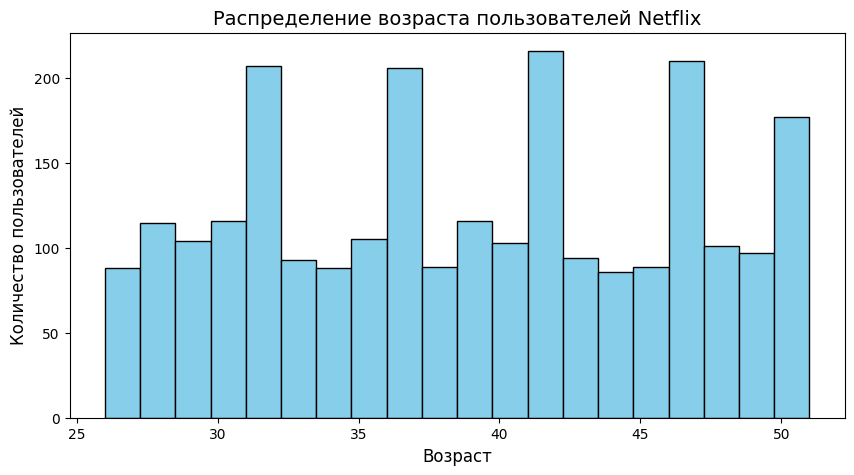

In [5]:
if age_col and age_col in df.columns:
    print("\n" + "="*50)
    print("📊 ВОЗРАСТ ПОЛЬЗОВАТЕЛЕЙ")
    print("="*50)

    # Убираем выбросы
    df_clean = df[(df[age_col] >= 18) & (df[age_col] <= 100)]
    print(f"📊 Средний возраст: {df_clean[age_col].mean():.1f}")
    print(f"📊 Медианный возраст: {df_clean[age_col].median():.1f}")

    plt.figure(figsize=(10, 5))
    df_clean[age_col].hist(bins=20, edgecolor='black', color='skyblue')
    plt.title('Распределение возраста пользователей Netflix', fontsize=14)
    plt.xlabel('Возраст', fontsize=12)
    plt.ylabel('Количество пользователей', fontsize=12)
    plt.grid(False)
    plt.show()


📊 ПОЛЬЗОВАТЕЛИ ПО ПОЛУ
Gender
Female    1257
Male      1243
Name: count, dtype: int64


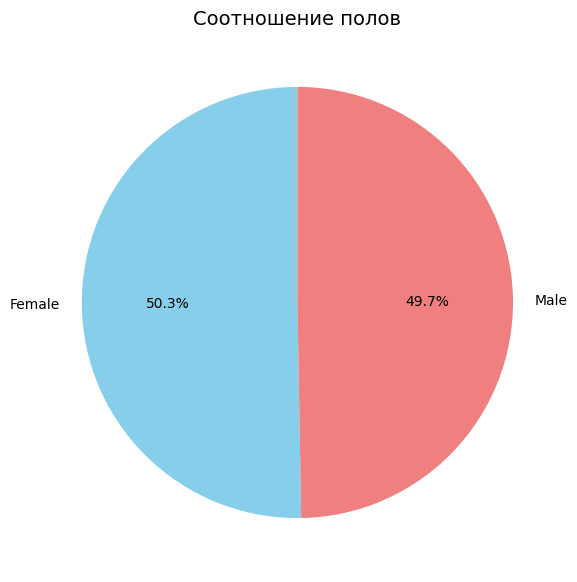

In [6]:
if gender_col and gender_col in df.columns:
    print("\n" + "="*50)
    print("📊 ПОЛЬЗОВАТЕЛИ ПО ПОЛУ")
    print("="*50)

    gender_counts = df[gender_col].value_counts()
    print(gender_counts)

    plt.figure(figsize=(7, 7))
    plt.pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['skyblue', 'lightcoral'])
    plt.title('Соотношение полов', fontsize=14)
    plt.show()


📊 ТИПЫ УСТРОЙСТВ
Device
Laptop        636
Tablet        633
Smartphone    621
Smart TV      610
Name: count, dtype: int64


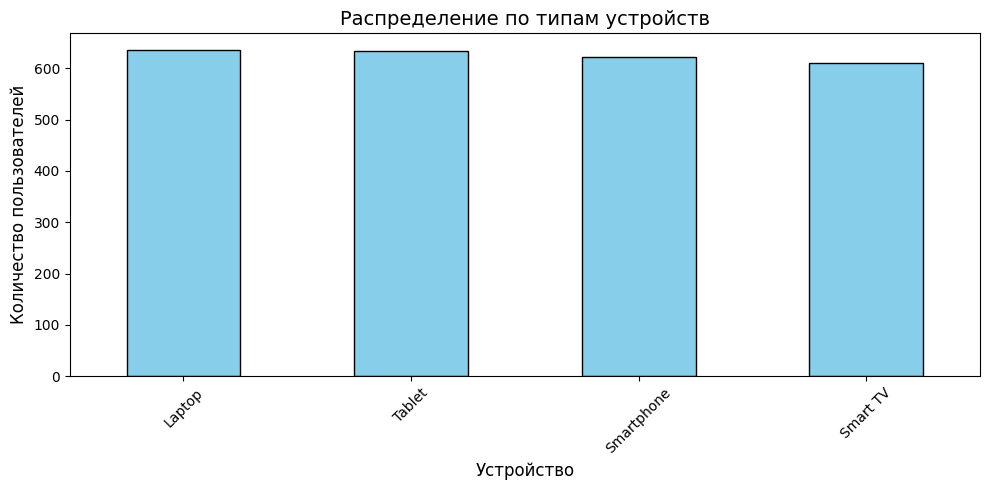

In [7]:
if device_col and device_col in df.columns:
    print("\n" + "="*50)
    print("📊 ТИПЫ УСТРОЙСТВ")
    print("="*50)

    device_counts = df[device_col].value_counts()
    print(device_counts)

    plt.figure(figsize=(10, 5))
    device_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Распределение по типам устройств', fontsize=14)
    plt.xlabel('Устройство', fontsize=12)
    plt.ylabel('Количество пользователей', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


📊 ТИПЫ ПОДПИСКИ
Subscription Type
Basic       999
Standard    768
Premium     733
Name: count, dtype: int64


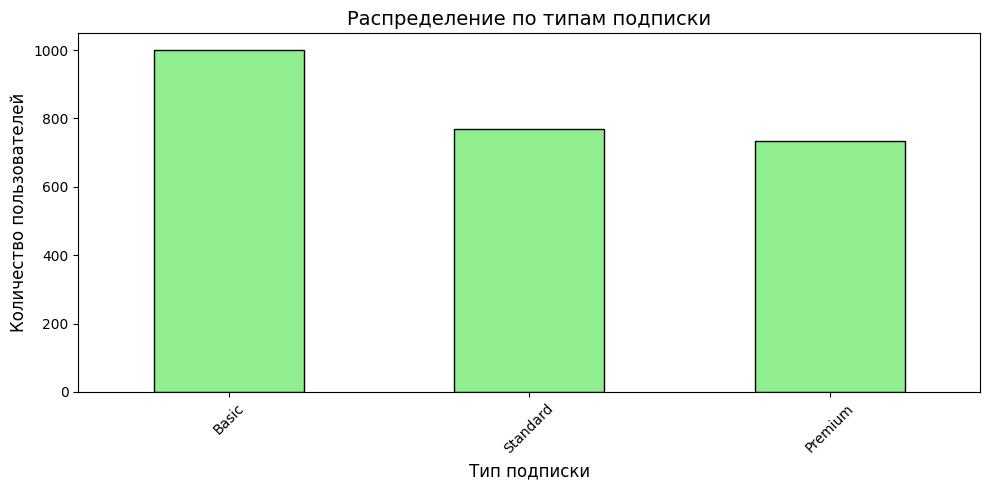

In [8]:
if sub_col and sub_col in df.columns:
    print("\n" + "="*50)
    print("📊 ТИПЫ ПОДПИСКИ")
    print("="*50)

    sub_counts = df[sub_col].value_counts()
    print(sub_counts)

    plt.figure(figsize=(10, 5))
    sub_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title('Распределение по типам подписки', fontsize=14)
    plt.xlabel('Тип подписки', fontsize=12)
    plt.ylabel('Количество пользователей', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


📊 СТРАНЫ ПОЛЬЗОВАТЕЛЕЙ
📊 Всего стран: 10
📊 Топ-10 стран:
   United States: 451
   Spain: 451
   Canada: 317
   United Kingdom: 183
   Germany: 183
   Australia: 183
   France: 183
   Brazil: 183
   Mexico: 183
   Italy: 183


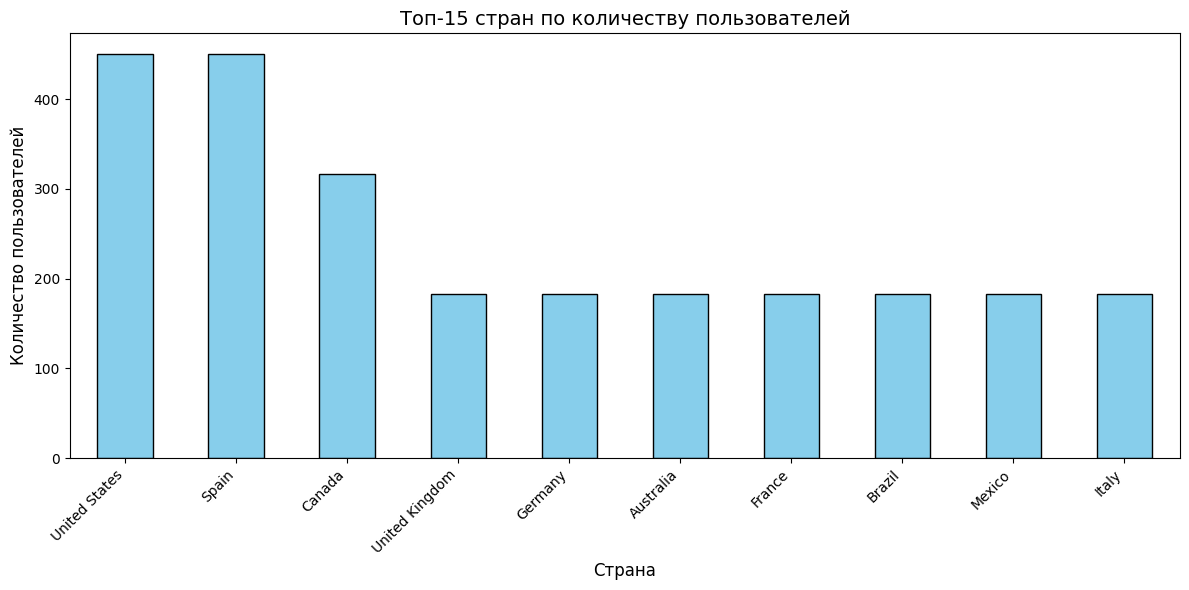

In [9]:
if country_col and country_col in df.columns:
    print("\n" + "="*50)
    print("📊 СТРАНЫ ПОЛЬЗОВАТЕЛЕЙ")
    print("="*50)

    country_counts = df[country_col].value_counts()
    print(f"📊 Всего стран: {len(country_counts)}")
    print(f"📊 Топ-10 стран:")
    for country, count in country_counts.head(10).items():
        print(f"   {country}: {count}")

    plt.figure(figsize=(12, 6))
    country_counts.head(15).plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Топ-15 стран по количеству пользователей', fontsize=14)
    plt.xlabel('Страна', fontsize=12)
    plt.ylabel('Количество пользователей', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


📊 ДИНАМИКА ПРИВЛЕЧЕНИЯ ПОЛЬЗОВАТЕЛЕЙ


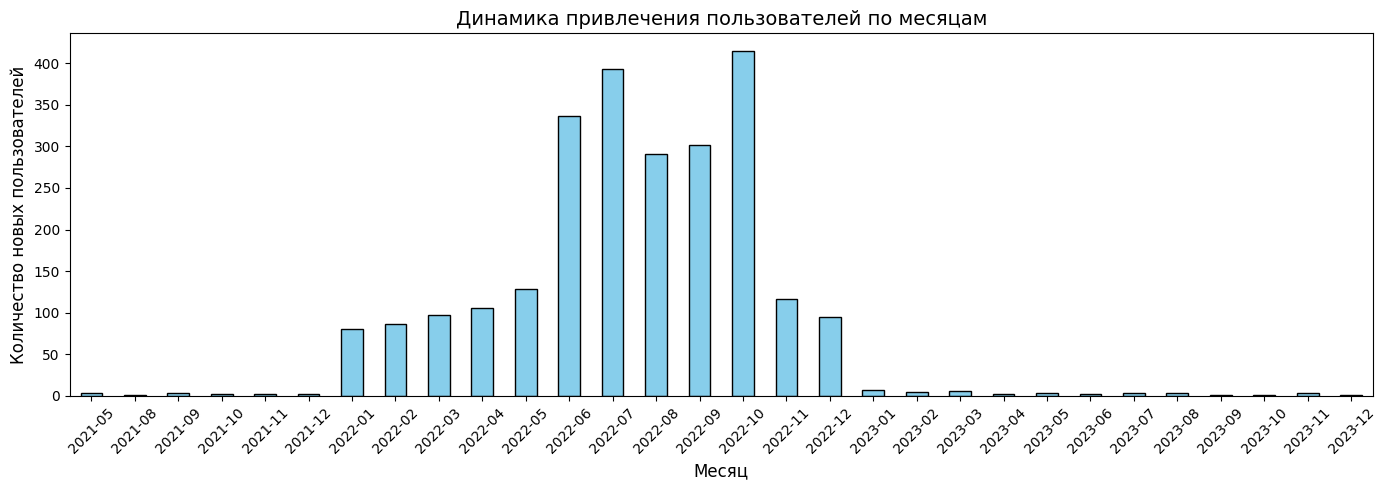

In [10]:
if join_col and join_col in df.columns:
    print("\n" + "="*50)
    print("📊 ДИНАМИКА ПРИВЛЕЧЕНИЯ ПОЛЬЗОВАТЕЛЕЙ")
    print("="*50)

    # Группируем по месяцу
    df['join_month'] = df[join_col].dt.to_period('M')
    monthly_join = df.groupby('join_month').size()

    plt.figure(figsize=(14, 5))
    monthly_join.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Динамика привлечения пользователей по месяцам', fontsize=14)
    plt.xlabel('Месяц', fontsize=12)
    plt.ylabel('Количество новых пользователей', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


📊 ПЛАТЕЖЕСПОСОБНОСТЬ ПО ВОЗРАСТНЫМ ГРУППАМ
age_group
36-45    12509
26-35    11492
46-55     7270
19-25        0
0-18         0
56-65        0
65+          0
Name: Monthly Revenue, dtype: int64


/tmp/ipykernel_5482/1237355712.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_revenue = df.groupby('age_group')[revenue_col].sum().sort_values(ascending=False)


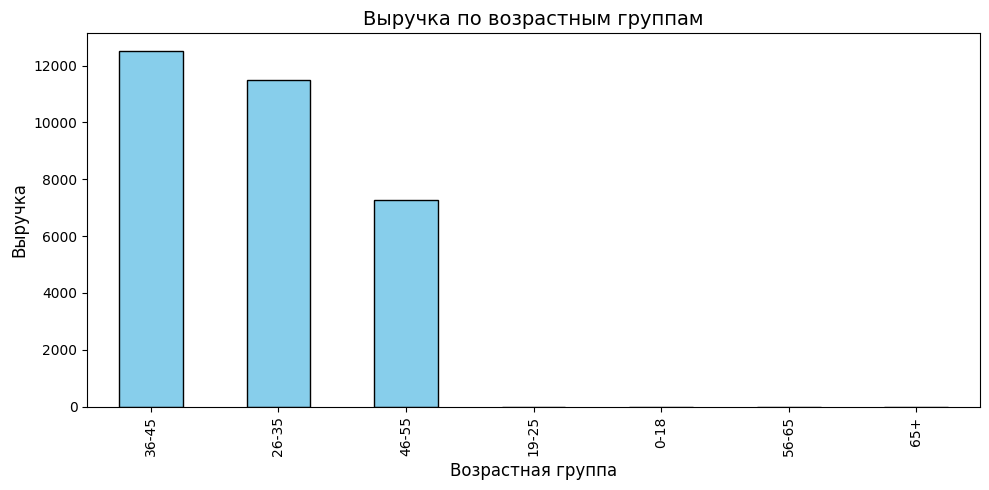

🏆 Самая платежеспособная группа: 36-45


In [11]:
if age_col and revenue_col:
    print("\n" + "="*50)
    print("📊 ПЛАТЕЖЕСПОСОБНОСТЬ ПО ВОЗРАСТНЫМ ГРУППАМ")
    print("="*50)

    # Создаем возрастные группы
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+']
    df['age_group'] = pd.cut(df[age_col], bins=bins, labels=labels)

    age_revenue = df.groupby('age_group')[revenue_col].sum().sort_values(ascending=False)
    print(age_revenue)

    plt.figure(figsize=(10, 5))
    age_revenue.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Выручка по возрастным группам', fontsize=14)
    plt.xlabel('Возрастная группа', fontsize=12)
    plt.ylabel('Выручка', fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"🏆 Самая платежеспособная группа: {age_revenue.index[0]}")


📊 ЗАВИСИМОСТЬ ТАРИФА ОТ ВОЗРАСТА
Subscription Type      Basic    Premium   Standard
age_group                                         
26-35              38.646288  31.113537  30.240175
36-45              40.540541  27.927928  31.531532
46-55              41.025641  28.888889  30.085470


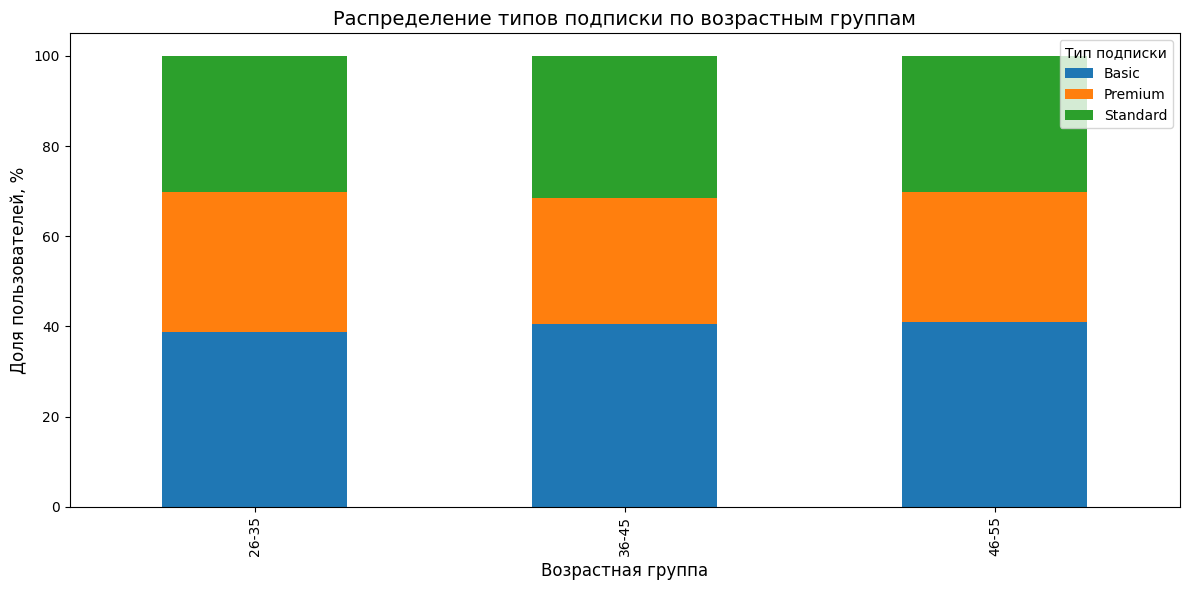

In [12]:
if sub_col and age_col:
    print("\n" + "="*50)
    print("📊 ЗАВИСИМОСТЬ ТАРИФА ОТ ВОЗРАСТА")
    print("="*50)

    # Сводная таблица
    pivot_age_sub = pd.crosstab(df['age_group'], df[sub_col], normalize='index') * 100
    print(pivot_age_sub)

    pivot_age_sub.plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.title('Распределение типов подписки по возрастным группам', fontsize=14)
    plt.xlabel('Возрастная группа', fontsize=12)
    plt.ylabel('Доля пользователей, %', fontsize=12)
    plt.legend(title='Тип подписки')
    plt.tight_layout()
    plt.show()